In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


In [3]:
def load_usb_csv(csv_path: Path) -> np.ndarray:
    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
    if data.ndim == 1:
        data = data[:, np.newaxis]
    return data.astype(np.float64)

In [4]:
calib_path = Path("calibration.csv")
press_path = Path("press.csv")

calib_data = load_usb_csv(calib_path)
press_data = load_usb_csv(press_path)
print("Calibration Data Shape:", calib_data.shape)
print("Press Data Shape:", press_data.shape)

calib_data = calib_data * (3.3 / 4095)  # convert to voltage
press_data = press_data * (3.3 / 4095)  # convert to voltage

time = np.arange(len(calib_data)) * (1/6.25)  # time vector based on sampling rate


Calibration Data Shape: (766, 1000)
Press Data Shape: (766, 1000)


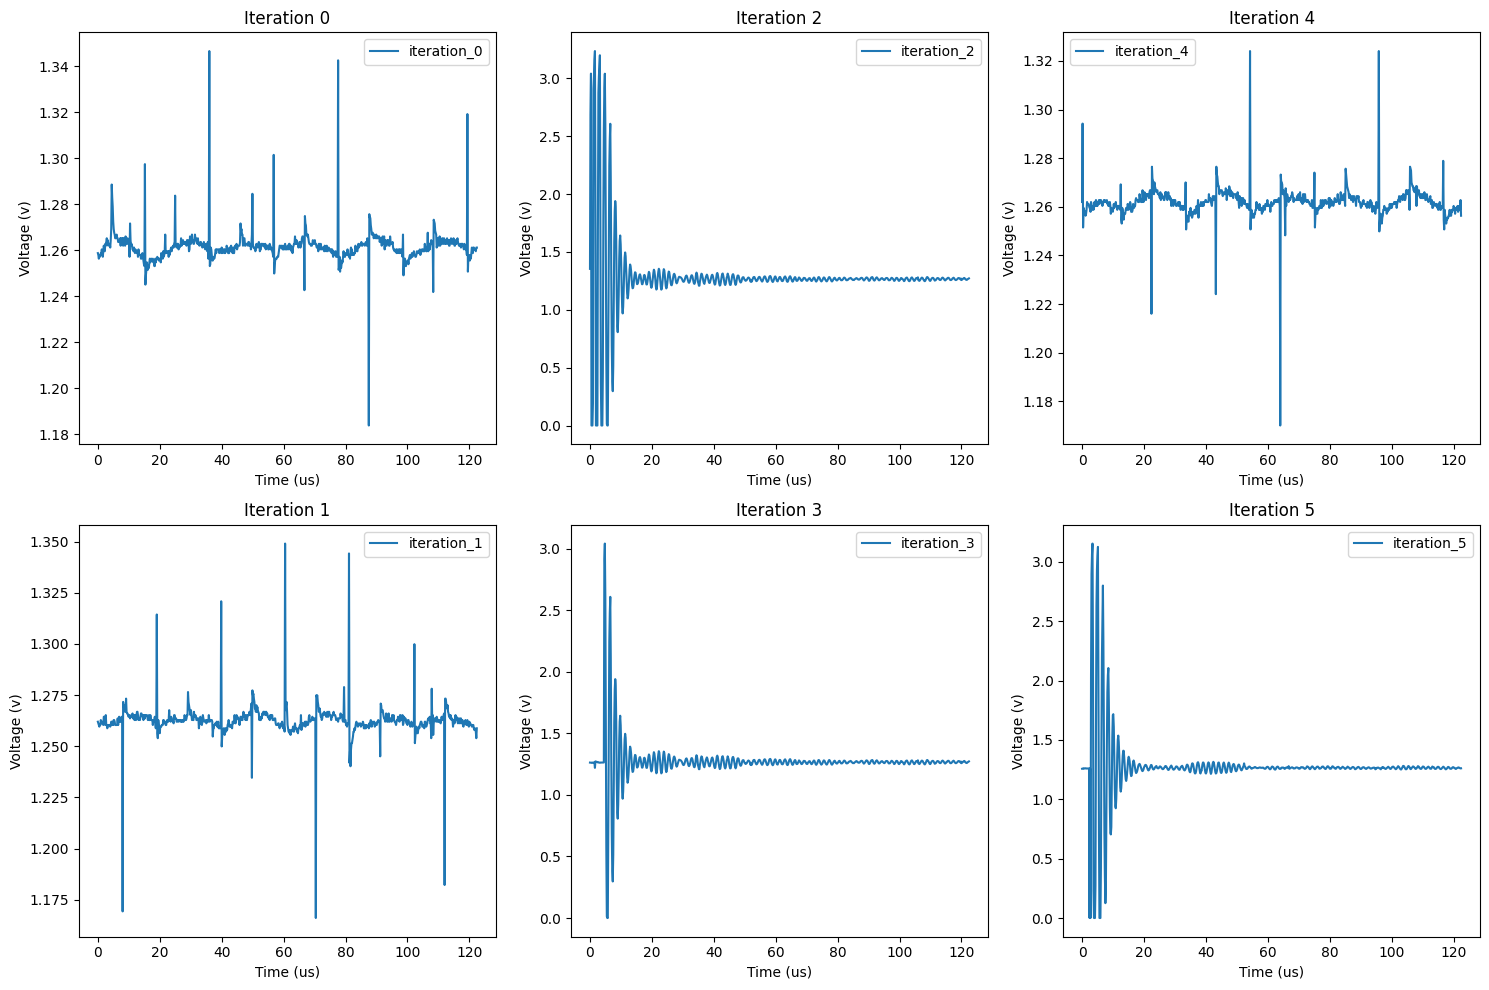

In [5]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for i in range(6):  
    row, col = i % 2, i // 2
    axs[row, col].plot(time, calib_data[:,i+18], label=f'iteration_{i}')
    axs[row, col].set_title(f'Iteration {i}')
    axs[row, col].set_xlabel('Time (us)')
    axs[row, col].set_ylabel('Voltage (v)')
    axs[row, col].legend()
plt.tight_layout()
plt.show()

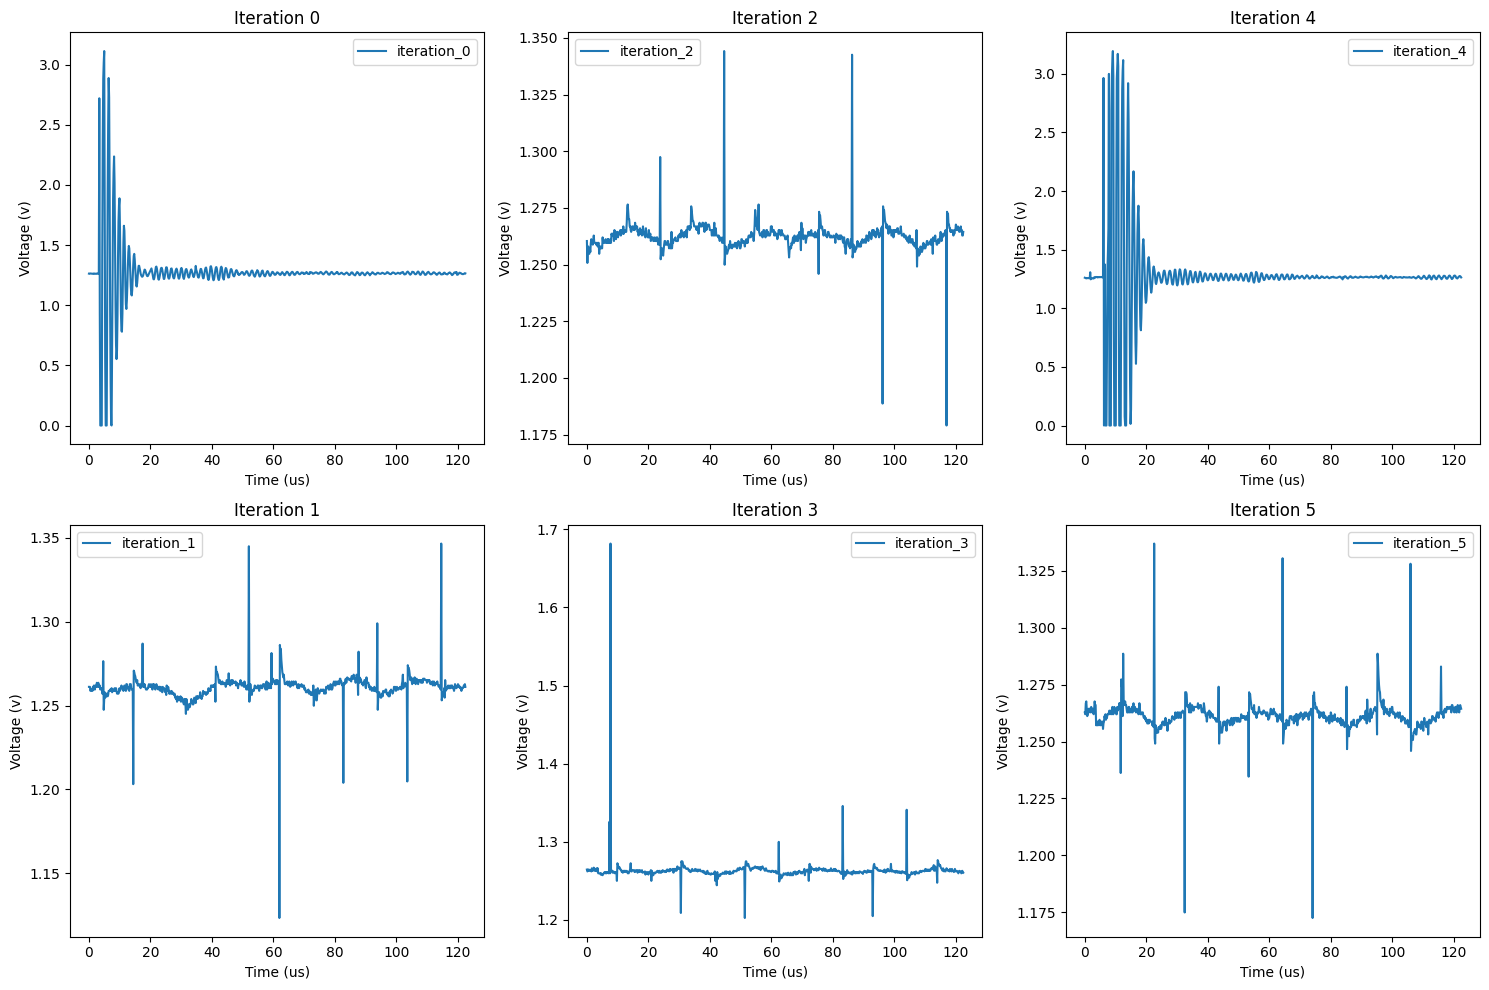

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
offset = 18
for i in range(6):  
    row, col = i % 2, i // 2
    axs[row, col].plot(time, press_data[:,i+offset], label=f'iteration_{i}')
    axs[row, col].set_title(f'Iteration {i}')
    axs[row, col].set_xlabel('Time (us)')
    axs[row, col].set_ylabel('Voltage (v)')
    axs[row, col].legend()
plt.tight_layout()
plt.show()

#18


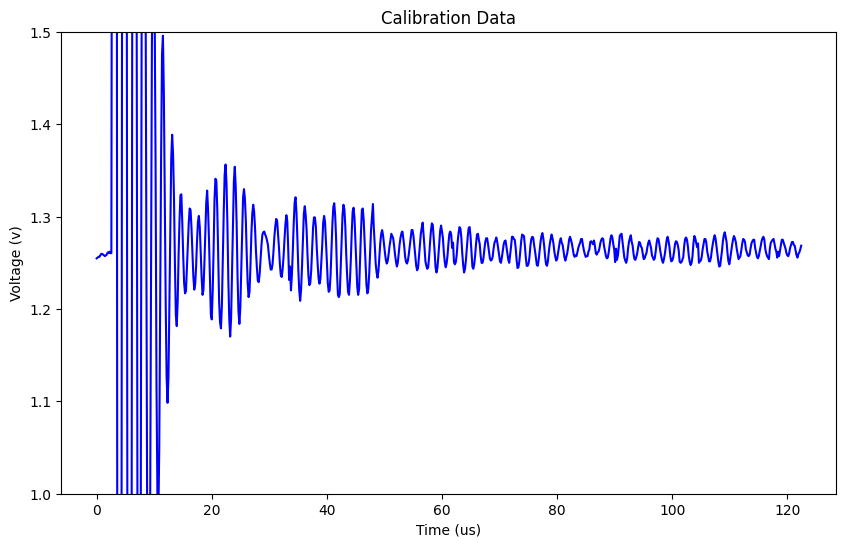

In [11]:
calib = calib_data[:, 1]
press = press_data[:, 18]

phase_shift = 0  # example phase shift in seconds

# shift press data by phase shift
shifted_press = np.roll(press, phase_shift)

plt.figure(figsize=(10, 6))
plt.plot(time, calib, label='Calibration', color='blue')
# plt.plot(time, shifted_press, label='Press', color='orange')
plt.title('Calibration Data')  
# plt.title('Calibration vs Press Data')  
# plt.legend()
plt.ylim(1, 1.5)  # set y-axis limits for better visualization
# plt.xlim(0, 80)  # set x-axis limits for better visualization
plt.xlabel('Time (us)')
plt.ylabel('Voltage (v)')
plt.show()

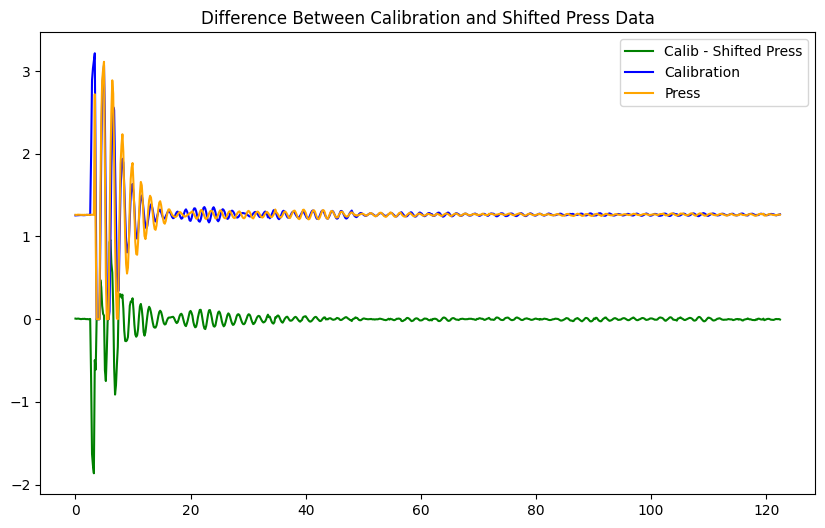

In [ ]:
phase_shift = 0  # example phase shift in seconds

# shift press data by phase shift
shifted_press = np.roll(press, phase_shift)
# subtract press from calib
diff = shifted_press - calib
# diff = calib - shifted_press

plt.figure(figsize=(10, 6))
plt.plot(time, diff, label='Calib - Shifted Press', color='green')
plt.plot(time, calib, label='Calibration', color='blue')
plt.plot(time, shifted_press, label='Press', color='orange')
plt.title('Difference Between Calibration and Shifted Press Data')
plt.legend()
plt.show()